## Importing libraries

In [1]:
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit.transpiler import generate_preset_pass_manager
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Declaring Constants
- Important to note `API_TOKEN` is required for sending and retriving jobs which can be obtain from the [IBM Quantum Platform](https://quantum.ibm.com/).
- `IBM_BACKEND` can be toggled to a specific QPU to send jobs to. Full list of QPUs can be found on [IBM Quantum processing units](https://quantum.ibm.com/services/resources).

In [ ]:
API_TOKEN = "INSERT API TOKEN HERE"
IBM_SERVICE = QiskitRuntimeService(channel="ibm_quantum", token=API_TOKEN)
IBM_BACKEND = IBM_SERVICE.backend("ibm_brisbane")

TRANPILE_SEED = 0
OPTIMIZATION_LEVEL = 0

MAX_QUBIT_COUNT = 127
VICTIM_QUBIT_POSITIONS = [i for i in range(0, MAX_QUBIT_COUNT, 2)]
ATTACKER_QUBIT_POSITIONS = [i for i in range(MAX_QUBIT_COUNT) if i not in VICTIM_QUBIT_POSITIONS]
SIMON_N = len(VICTIM_QUBIT_POSITIONS) // 2

HIGH_TO_LOW = "High-to-Low"
DEFAULT_TOPOLOGY = "Default"
LOW_TO_HIGH = "Low-to-High"

## Largest Possible Victim Circuit Size

In [3]:
print(len(VICTIM_QUBIT_POSITIONS))

64


## Biggest Simon Shift s size

In [4]:
print(SIMON_N)

32


## Simon's Algorithm
- The Simon circuit implementation is adapted from [simon.ipynb](https://github.com/qiskit-community/qiskit-textbook/blob/main/content/ch-algorithms/simon.ipynb) which is found on the [Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/grover.ipynb) Github Repo and this [medium](https://medium.com/@_monitsharma/learn-quantum-computing-with-qiskit-simons-algorithm-8525adecd091) article.

In [5]:
def simon_oracle(b):
    b = b[::-1] # reverse b for easy iteration
    n = len(b)
    qc = QuantumCircuit(n*2)
    # Do copy; |x>|0> -> |x>|x>
    for q in range(n):
        qc.cx(q, q+n)
    if '1' not in b:
        return qc  # 1:1 mapping, so just exit
    i = b.find('1') # index of first non-zero bit in b
    
    # Do |x> -> |s.x> on condition that q_i is 1
    for q in range(n):
        if b[q] == '1':
            qc.cx(i, (q)+n)
    return qc

## Attacker's Empty Listening Circuit and Victim's Simon Circuit
- For the passive attack we pivoted from Grover's Algorithm to Simon's Algorithm as it is easier to scale up in size without increasing the circuit depth aggressively. 
- For varying sizes of the Simon's Oracle it is assumed that the oracle consist of all 1s (e.g. $|1\rangle$, $|11\rangle$, $|111\rangle$, ...) to prevent exhaustively trying out all values of the oracle which would take exponential time. ($2^n$)
- The attacker is able to use all the remaining available qubits that are not occupied by the largest possible victim circuit

In [6]:
def victim_simon_and_attacker_listening_circuits(b, attacker_qubits = ATTACKER_QUBIT_POSITIONS):
    n = len(b)
    qc = QuantumCircuit(127, len(attacker_qubits))

    # Apply Hadamard gates before querying the oracle
    qc.h(range(n))

    # Apply barrier for visual separation
    qc.barrier()

    qc = qc.compose(simon_oracle(b))

    # Apply barrier for visual separation
    qc.barrier()

    # Apply Hadamard gates to the input register
    qc.h(range(n))

    qc.barrier()


    qc.measure(range(127-len(attacker_qubits), 127), range(len(attacker_qubits)))

    return qc

## Drawing the Circuit to Visualize the Victim’s Circuit and Attacker’s Listening Qubits
- In this example we use simon oracle $|111\rangle$
- Important to note that the attacker does not use all the unoccupied qubits for listening because there are qubits that are used by the largest possible victim circuit thus the attacker is not allowed to access those qubits (i.e. notice that the first attacker's listening qubit starts from $q\_64$)

In [7]:
qc = victim_simon_and_attacker_listening_circuits('111')
qc.draw()

┌───┐ ░                                ░ ┌───┐ ░                      »
  q_0: ┤ H ├─░───■──────────────■────■────■───░─┤ H ├─░──────────────────────»
       ├───┤ ░   │              │    │    │   ░ ├───┤ ░                      »
  q_1: ┤ H ├─░───┼────■─────────┼────┼────┼───░─┤ H ├─░──────────────────────»
       ├───┤ ░   │    │         │    │    │   ░ ├───┤ ░                      »
  q_2: ┤ H ├─░───┼────┼────■────┼────┼────┼───░─┤ H ├─░──────────────────────»
       └───┘ ░ ┌─┴─┐  │    │  ┌─┴─┐  │    │   ░ └───┘ ░                      »
  q_3: ──────░─┤ X ├──┼────┼──┤ X ├──┼────┼───░───────░──────────────────────»
             ░ └───┘┌─┴─┐  │  └───┘┌─┴─┐  │   ░       ░                      »
  q_4: ──────░──────┤ X ├──┼───────┤ X ├──┼───░───────░──────────────────────»
             ░      └───┘┌─┴─┐     └───┘┌─┴─┐ ░       ░                      »
  q_5: ──────░───────────┤ X ├──────────┤ X ├─░───────░──────────────────────»
             ░           └───┘          └───┘ ░       ░                      »
  q_6: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
  q_7: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
  q_8: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
  q_9: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_10: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_11: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_12: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_13: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_14: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_15: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_16: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_17: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_18: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_19: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_20: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_21: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_22: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_23: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░                      »
 q_24: ──────░────────────────────────────────░───────░──────────────────────»
             ░                                ░       ░  

## Get Evenly Spaced Out Qubits
- Important to note: having evenly spaced out qubits is important to ensure that the victim qubits are spaced out as far away as possible and also evenly spaced out between each qubit. This allows for maximum overlap of swap paths against the attacker's listening qubits

In [8]:
def get_spaced_elements(arr, n):
    if n <= 1 or n > len(arr):
        raise("Invalid n value")
    else:
        if n == len(arr):
            indices = [i for i in range(len(arr))]
        else:
            indices = np.linspace(0, len(arr)-1, n, dtype=int).tolist()
        
        ans = [arr[i] for i in indices]
        diff = [indices[i] - indices[i-1] - 1 for i in range(1, len(indices))]

        if n == len(arr) and ans != arr:
            raise("Wrong return arr for max n")
        
        if max(diff) - min(diff) > 1:
            raise("Too Big Gap")

        if len(ans) != len(diff) + 1:
            raise("Diff does not have the correct length")
    
        if len(set(ans)) != len(ans):
            raise("Values are not unique")

        if len(ans) != n:
            raise("Return arr has wrong length")
        
        return ans


## Transpiling the circuits to the real IBM QPU
- Important to note: when generating a pass manager using `generate_preset_pass_manager` the `seed_transpiler` is fixed to a consant `TRANPILE_SEED` to ensure consistant swap paths between runs
- `OPTIMIZATION_LEVEL` is fixed to `0` by default but could be changed however both learn and test jobs must share the same optimization level


In [9]:
run_list = []
qc_list = []

print(f"""
VICTIM_QUBIT_POSITIONS: {VICTIM_QUBIT_POSITIONS}
VICTIM_QUBIT_POSITIONS len: {len(VICTIM_QUBIT_POSITIONS)}

ATTACKER_QUBIT_POSITIONS: {ATTACKER_QUBIT_POSITIONS}
ATTACKER_QUBIT_POSITIONS len: {len(ATTACKER_QUBIT_POSITIONS)}
""")

if not 2 <= 2*SIMON_N <= len(VICTIM_QUBIT_POSITIONS):
    raise Exception(f"n: {SIMON_N} does not statisfy: 2 <= 2*n <= {len(VICTIM_QUBIT_POSITIONS)}")

for b in ['1'*i for i in range(1, SIMON_N+1)]:
    qc = victim_simon_and_attacker_listening_circuits(b)
    qc_list.append(qc)
    total_n = len(b)*2

    victim_qubits = get_spaced_elements(VICTIM_QUBIT_POSITIONS, total_n)
    unused_victim_qubits = sorted(set(VICTIM_QUBIT_POSITIONS) - set(victim_qubits))
    qubit_layout = victim_qubits + unused_victim_qubits + ATTACKER_QUBIT_POSITIONS
    print(total_n, qubit_layout)

    pm = generate_preset_pass_manager(backend=IBM_BACKEND, seed_transpiler=TRANPILE_SEED, optimization_level = OPTIMIZATION_LEVEL, initial_layout = qubit_layout)
    tqc = pm.run(qc)
    run_list.append(tqc)

tranpiled_len = len(run_list)
print(f"transpile_side_channel done: length of run_list ({tranpiled_len})")


VICTIM_QUBIT_POSITIONS: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126]
VICTIM_QUBIT_POSITIONS len: 64

ATTACKER_QUBIT_POSITIONS: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 49, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 113, 115, 117, 119, 121, 123, 125]
ATTACKER_QUBIT_POSITIONS len: 63

2 [0, 126, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 4

## Send Job Function
- This function is required to be called twice: once for learning and once for test (actual attack to evaluate the accuracy of prediction)
- The 2 job could be either sent back to back or with a delay (Important to note: if a delay is introduced the quantum calibration of the QPU may cause deviation in the signature collected by the atttacker's listening qubits)
- Addition safeguard is added to the send job function in case of accidental execution. User is required to enter `"RUN"` in order for the job to be successfully send to the IBM quantum device

In [10]:
def send_job():
    print(f"backend`: {IBM_BACKEND.name}")

    run_list_len = len(run_list)
    print(f"run_list length: {run_list_len}")

    time_taken_in_seconds = run_list_len * 1.17
    time_taken_in_mins = time_taken_in_seconds/60
    print(f"Estimated Time: {time_taken_in_seconds:.2f}s ({time_taken_in_mins:.2f} mins)")


    if input("Enter RUN: ") == "RUN":
        print("\nSending Job Now")
        sampler = Sampler(mode=IBM_BACKEND)
        job = sampler.run(run_list)
        print(f"job id: {job.job_id()}")
    
    return job

## Learn Job
- Job is sent once for the learning

In [ ]:
learn_job = send_job()

## Test Job
- Job is sent the second time for the attack prediction

In [ ]:
test_job = send_job()

## Check Job Status
- To check the status of a job, user may run the following code snippet or check the [IBM Quantum Platform](https://quantum.ibm.com/)

In [ ]:
test_job.status()

## Get Job Id Function

In [14]:
def get_job(job_id):
    return IBM_SERVICE.job(job_id)

## Functions for the Passive Side Channel Attack

In [15]:
def mean_squared_error(list1, list2):
    return sum((a - b) ** 2 for a, b in zip(list1, list2)) / len(list1)

def ones_count(result, qubit_index_map, valid_qubits):
    counts = result.data.c.get_counts()
    n = len(list(counts.keys())[0])
    
    if n != len(qubit_index_map):
        raise Exception("n != len(qubit_index_map)")
    
    if not set(valid_qubits).issubset(set(qubit_index_map)):
        raise Exception("not set(valid_qubits).issubset(set(qubit_index_map))")

    qubit_one_counts = {i: 0 for i in qubit_index_map}
    
    for bin, cnt in counts.items():
        for i, c in enumerate(bin):
            if c == '1' and qubit_index_map[i] in valid_qubits:
                qubit_one_counts[qubit_index_map[i]] += 1
    return qubit_one_counts

def get_result_values(results, valid_qubits):
    values = []

    for result in results:
        values.append(list(ones_count(result, ATTACKER_QUBIT_POSITIONS, valid_qubits).values()))

    return values

def get_mse_matrix(learn_results, test_results, valid_qubits):
    learn_values = get_result_values(learn_results, valid_qubits)
    test_values = get_result_values(test_results, valid_qubits)
    n = len(learn_values)
    
    ans = []

    for i in range(n):
        row = [mean_squared_error(learn_values[i], test_values[j]) for j in range(n)]
        max_value = max(row)
        row = [value/max_value for value in row]
        ans.append(row)
    return ans

def get_sorted_valid_qubits(results):
    max_values = [[float('inf'), -float('inf')] for _ in range(len(ATTACKER_QUBIT_POSITIONS))]
    for simon_qubit_experiment in get_result_values(results, ATTACKER_QUBIT_POSITIONS):
        for i, cnt in enumerate(simon_qubit_experiment):
            max_values[i][0] = min(max_values[i][0], cnt)
            max_values[i][1] = max(max_values[i][1], cnt)
    max_abs = [max_value - min_value for min_value, max_value in max_values]
    qubit_max_abs = sorted([[max_abs[i], qubit] for i, qubit in enumerate(ATTACKER_QUBIT_POSITIONS)], reverse=True)
    valid_qubits = [qubit for mse_value, qubit in qubit_max_abs]
    return valid_qubits


def get_min_accuracy(matrix):
    if len(matrix) != len(matrix[0]) or len(matrix) == 0:
        raise Exception("len(matrix) != len(matrix[0]) or len(matrix) == 0")
    min_accuracy = float('inf')
    n = len(matrix)
    for i in range(n):
        rankings = sorted([[matrix[i][j], j] for j in range(n)])

        target_rank = None
        for rank_index in range(n):
            if rankings[rank_index][1] == i:
                target_rank = rank_index
                break
        accuracy = (n-target_rank)/n
        min_accuracy = min(min_accuracy, accuracy)
        
    return min_accuracy

def get_average_mse_confidence(matrix):
    if len(matrix) != len(matrix[0]) or len(matrix) == 0:
        raise Exception("len(matrix) != len(matrix[0]) or len(matrix) == 0")
    
    confidence_sum = 0
    n = len(matrix)

    for i in range(n):
        rankings = sorted([[matrix[i][j], j] for j in range(n)])

        target_rank = None
        for rank_index in range(n):
            if rankings[rank_index][1] == i:
                target_rank = rank_index
                break
        
        if target_rank != n-1:
            confidence = rankings[target_rank+1][0] - rankings[target_rank][0]
        else:
            confidence = 0
        
        confidence_sum += confidence
        
    return confidence_sum / n 

## Retrive the Learn Job

In [ ]:
learn_results = get_job('INSERT LEARN JOB ID HERE').result()

## Retrive the Test Job

In [ ]:
test_results = get_job('INSERT TEST JOB ID HERE').result()

## Function to Display and Save the Mse Matrix

In [18]:
def save_mse_matrix(valid_qubits_count, valid_qubits_type, cmap='coolwarm'):
    n = len(learn_results)

    A_label, B_label = "Learn", "Test"

    valid_qubits_dict = {DEFAULT_TOPOLOGY:ATTACKER_QUBIT_POSITIONS,
                    HIGH_TO_LOW: get_sorted_valid_qubits(learn_results),
                    LOW_TO_HIGH: get_sorted_valid_qubits(learn_results)[::-1]}
    valid_qubits = valid_qubits_dict[valid_qubits_type]

    similarity_matrix = get_mse_matrix(learn_results, test_results, valid_qubits[:valid_qubits_count])

    sns.set_context("notebook", font_scale= 2)
    
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.figure(figsize=(8, 6))

    qubits = [(i+1)*2 for i in range(n)]
    interval = 4
    labels = [qubits[i] for i in range(0, len(qubits), interval)]
    ticks = [i + 0.5 for i in range(0, n, interval)]

    sns.heatmap(similarity_matrix, annot=False, cmap=cmap, cbar=True)  

    plt.xticks(ticks=ticks, labels=labels)
    plt.yticks(ticks=ticks, labels=labels)
    plt.xlabel(f"{B_label} (Qubits)")
    plt.ylabel(f"{A_label} (Qubits)")
    # plt.savefig(f'mse_matrix_{valid_qubits_type.lower()}_{valid_qubits_count}.pdf', format='pdf', bbox_inches='tight')
    plt.show()

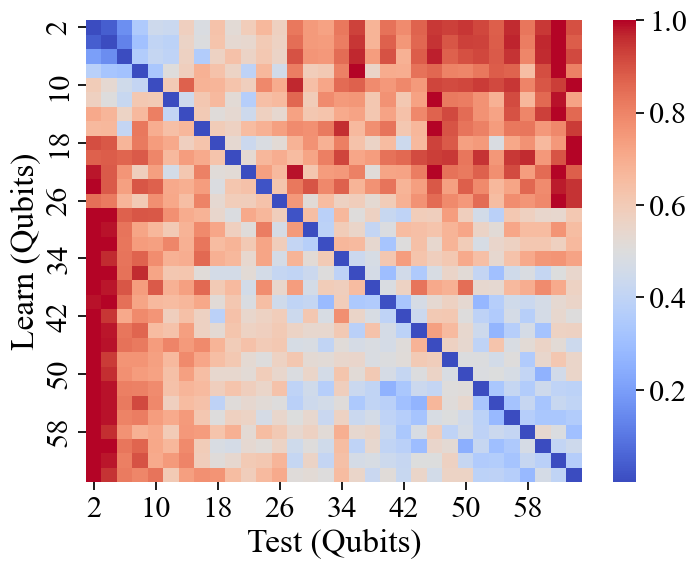

In [19]:
save_mse_matrix(63, HIGH_TO_LOW)

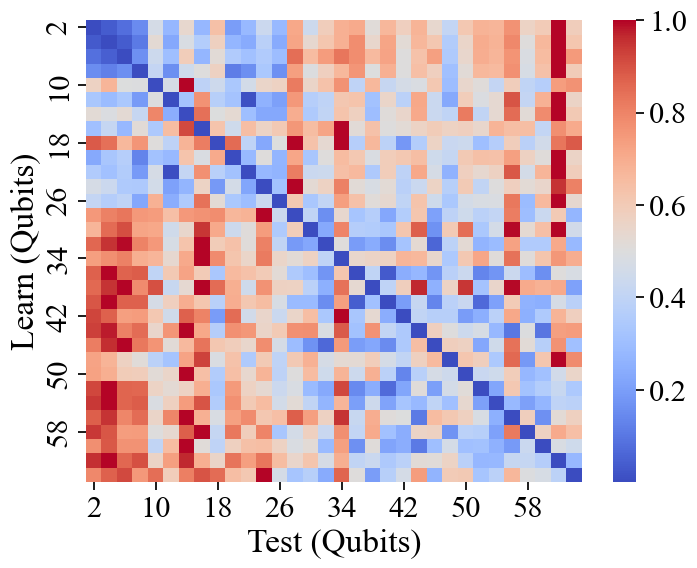

In [20]:
save_mse_matrix(11, HIGH_TO_LOW)

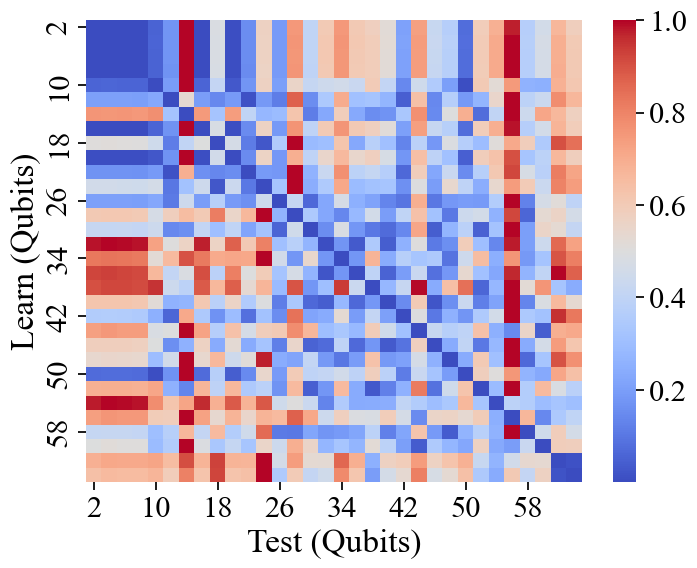

In [21]:
save_mse_matrix(4, HIGH_TO_LOW)

## Reducing the Number of Qubits Used for the Listening Circuit
- 3 ways to select qubits for the listening circuit: HIGH_TO_LOW, DEFAULT_TOPOLOGY, LOW_TO_HIGH

In [22]:
high_to_low_qubits = get_sorted_valid_qubits(learn_results) 
default_topology_qubits = ATTACKER_QUBIT_POSITIONS
low_to_high_qubits = high_to_low_qubits[::-1]

number_of_listening_qubits = []

high_to_low_qubits_acc = []
default_topology_qubits_acc = []
low_to_high_qubits_acc = []

high_to_low_qubits_confidence = []
default_topology_qubits_confidence = []
low_to_high_qubits_confidence = []

for qubit_count in range(1, len(ATTACKER_QUBIT_POSITIONS)):
    number_of_listening_qubits.append(qubit_count)

    high_to_low_qubits_mse_matrix = get_mse_matrix(learn_results, test_results, high_to_low_qubits[:qubit_count])
    default_topology_qubits_mse_matrix = get_mse_matrix(learn_results, test_results, default_topology_qubits[:qubit_count])
    low_to_high_qubits_mse_matrix = get_mse_matrix(learn_results, test_results, low_to_high_qubits[:qubit_count])

    high_to_low_qubits_acc.append(get_min_accuracy(high_to_low_qubits_mse_matrix))
    default_topology_qubits_acc.append(get_min_accuracy(default_topology_qubits_mse_matrix))
    low_to_high_qubits_acc.append(get_min_accuracy(low_to_high_qubits_mse_matrix))
    
    high_to_low_qubits_confidence.append(get_average_mse_confidence(high_to_low_qubits_mse_matrix))
    default_topology_qubits_confidence.append(get_average_mse_confidence(default_topology_qubits_mse_matrix))
    low_to_high_qubits_confidence.append(get_average_mse_confidence(low_to_high_qubits_mse_matrix))
    
    print(f"{qubit_count} qubits done")


1 qubits done
2 qubits done
3 qubits done
4 qubits done
5 qubits done
6 qubits done
7 qubits done
8 qubits done
9 qubits done
10 qubits done
11 qubits done
12 qubits done
13 qubits done
14 qubits done
15 qubits done
16 qubits done
17 qubits done
18 qubits done
19 qubits done
20 qubits done
21 qubits done
22 qubits done
23 qubits done
24 qubits done
25 qubits done
26 qubits done
27 qubits done
28 qubits done
29 qubits done
30 qubits done
31 qubits done
32 qubits done
33 qubits done
34 qubits done
35 qubits done
36 qubits done
37 qubits done
38 qubits done
39 qubits done
40 qubits done
41 qubits done
42 qubits done
43 qubits done
44 qubits done
45 qubits done
46 qubits done
47 qubits done
48 qubits done
49 qubits done
50 qubits done
51 qubits done
52 qubits done
53 qubits done
54 qubits done
55 qubits done
56 qubits done
57 qubits done
58 qubits done
59 qubits done
60 qubits done
61 qubits done
62 qubits done


## Investigate the Minimum Number of Qubits Required for 100% Prediction Accuracy

In [23]:
for i in range(len(number_of_listening_qubits)):
    if high_to_low_qubits_acc[i] == 1:
        print(f"Min Qubits Required for 100% Prediction: {i+1} Qubits ({HIGH_TO_LOW})")
        break

for i in range(len(number_of_listening_qubits)):
    if default_topology_qubits_acc[i] == 1:
        print(f"Min Qubits Required for 100% Prediction: {i+1} Qubits ({DEFAULT_TOPOLOGY})")
        break

for i in range(len(number_of_listening_qubits)):
    if low_to_high_qubits_acc[i] == 1:
        print(f"Min Qubits Required for 100% Prediction: {i+1} Qubits ({LOW_TO_HIGH})")
        break


Min Qubits Required for 100% Prediction: 4 Qubits (High-to-Low)
Min Qubits Required for 100% Prediction: 11 Qubits (Default)
Min Qubits Required for 100% Prediction: 11 Qubits (Low-to-High)


## Plot the Number of qubits used against the accuracy and confidence of prediction

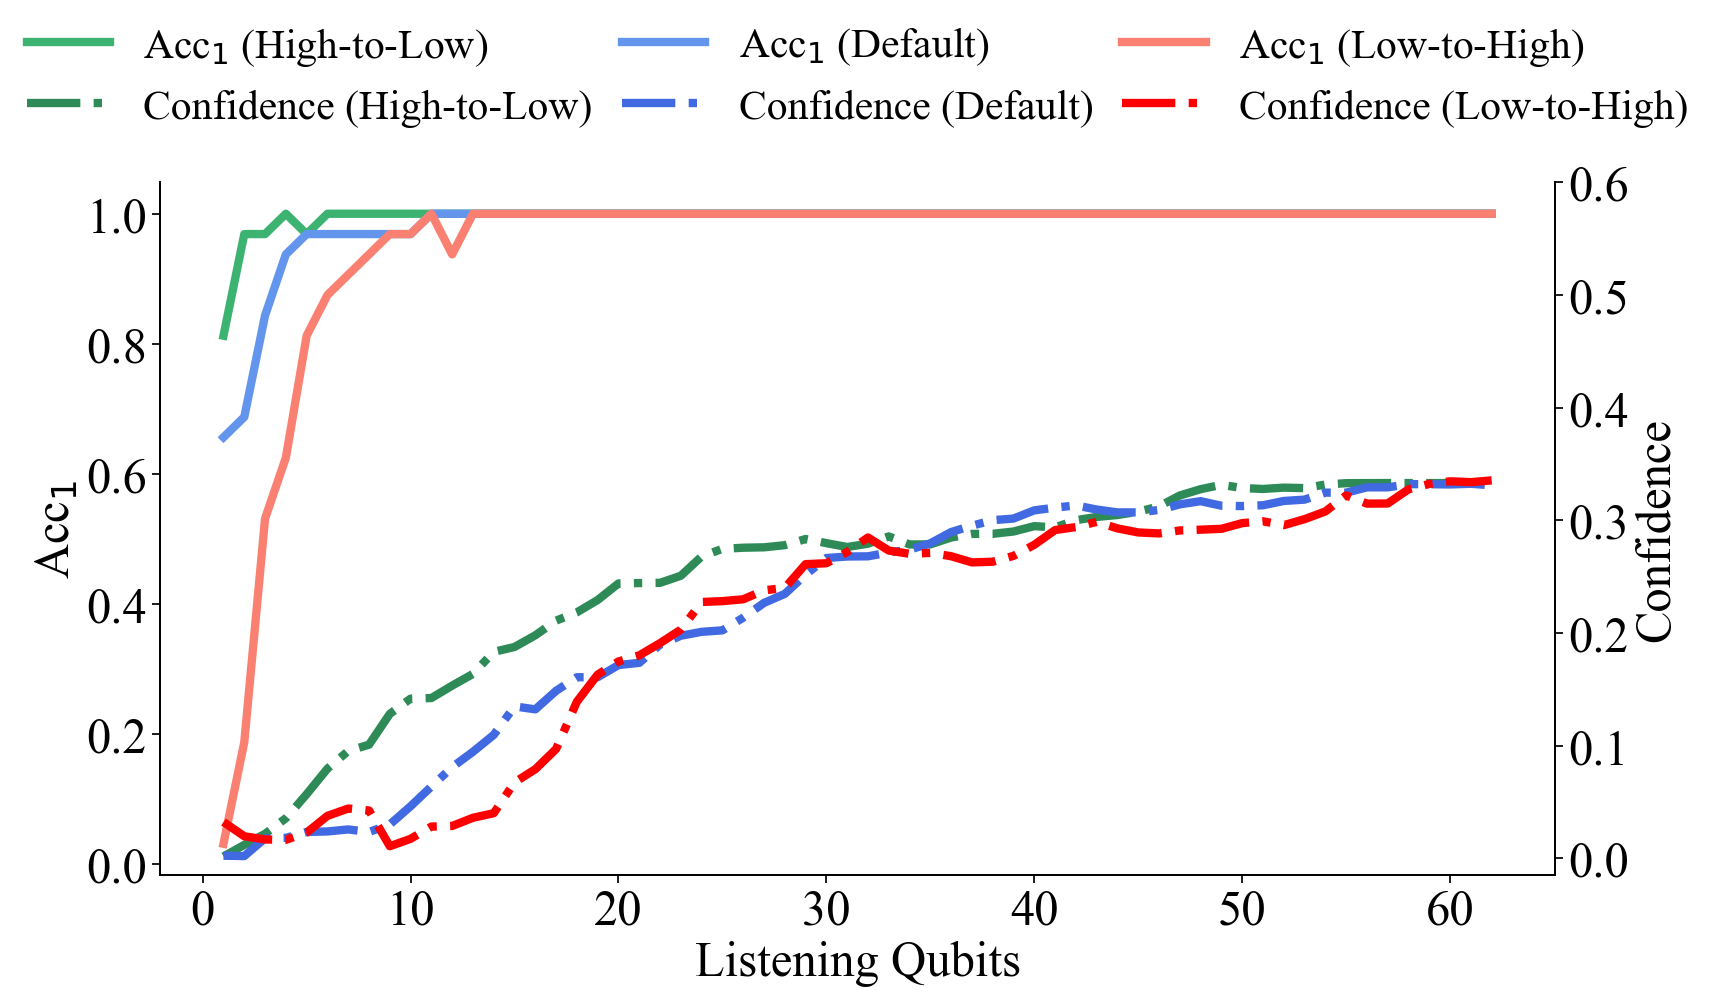

In [24]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 40

fig, ax1 = plt.subplots(figsize=(18, 9))
ax2 = ax1.twinx()

linewidth = 6
fontsize = 35
linestyle = 'dashdot'

g = 'seagreen' 
lg = 'mediumseagreen'
b = 'royalblue'
lb = 'cornflowerblue'
r = 'red'
lr = 'salmon'

g, lg = lg, g
b, lb = lb, b
r, lr = lr, r

ax1.plot(number_of_listening_qubits, high_to_low_qubits_acc, label=f'{r'Acc$_1$'} ({HIGH_TO_LOW})', color=g, linestyle='-', linewidth= linewidth )
ax2.plot(number_of_listening_qubits, high_to_low_qubits_confidence, label=f'Confidence ({HIGH_TO_LOW})', color=lg, linestyle=linestyle, linewidth= linewidth )

ax1.plot(number_of_listening_qubits, default_topology_qubits_acc, label=f'{r'Acc$_1$'} ({DEFAULT_TOPOLOGY})', color=b, linestyle='-', linewidth= linewidth )
ax2.plot(number_of_listening_qubits, default_topology_qubits_confidence, label=f'Confidence ({DEFAULT_TOPOLOGY})', color=lb, linestyle=linestyle, linewidth= linewidth )


ax1.plot(number_of_listening_qubits, low_to_high_qubits_acc, label=f'{r'Acc$_1$'} ({LOW_TO_HIGH})', color=r, linestyle='-', linewidth= linewidth )
ax2.plot(number_of_listening_qubits, low_to_high_qubits_confidence, label=f'Confidence ({LOW_TO_HIGH})', color=lr, linestyle=linestyle, linewidth= linewidth )

ax1.set_xlabel('Listening Qubits', fontsize = fontsize)
ax1.set_ylabel(r'Acc$_1$', fontsize = fontsize)
ax2.set_ylabel('Confidence', fontsize = fontsize)
# Increase font size for x and y axis tick labels
ax1.tick_params(axis='x', labelsize=fontsize)  # Increase x-axis tick label size
ax1.tick_params(axis='y', labelsize=fontsize)  # Increase y-axis tick label size
ax2.tick_params(axis='y', labelsize=fontsize)  # Increase y-axis tick label size for the second y-axis (ax2)

ax = plt.gca()  # Get current axes
ax1.spines['top'].set_visible(False)  # Remove top spine
ax2.spines['top'].set_visible(False)  # Remove top spine
ax2.set_ylim(top=0.6)

# Create a unified legend that includes both ax1 and ax2 labels
lines1, labels1 = ax1.get_legend_handles_labels()  # Get legend handles and labels from ax1
lines2, labels2 = ax2.get_legend_handles_labels()  # Get legend handles and labels from ax2

# Combine both handles and labels
lines = []
labels = []
for i in range(len(lines1)):
    lines.append(lines1[i])
    lines.append(lines2[i])
    labels.append(labels1[i])
    labels.append(labels2[i])

# Add the legend with the combined handles and labels
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=3, fontsize=30, columnspacing=0.7, frameon=False)

# plt.savefig('side_channel_accuracy.pdf', format='pdf',  bbox_inches='tight')
plt.show()
